In [1]:
# Scenario: Predicting Student Exam Scores
# A school wants to build a model to predict student exam scores based on study hours. They collect data
# from 30 students, but the scores are noisy because of other factors (like sleep, stress, or health).
# They try two different models:
# - Linear Model (straight line) → very simple, assumes scores increase perfectly with study hours.
# - Polynomial Model (degree 10 curve) → very complex, tries to follow every bump in the data.

# Questions
# - Part A: If the linear model consistently predicts too low or too high compared to actual scores,
# what does this show about bias?
# - Part B: If the polynomial model fits the training data almost perfectly but gives very different predictions when tested on new students, what does this show about variance?
# - Part C: Which model is likely to generalize better to new students, and why?
# - Part D (Applied): How would you explain the difference between “high bias” and “high variance” to
#  a teacher who doesn’t know machine learning?

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
# this allows model to learn curves instead of a straight line.
from sklearn.preprocessing import PolynomialFeatures
# Creates a pipeline to combine steps:
# Generate polynomial features and Apply Linear Regression
# So instead of manually transforming data and then fitting model, pipeline does both automatically.
from sklearn.pipeline import make_pipeline

In [8]:
np.random.seed(0)
X = np.linspace(0,6,30).reshape(-1,1)

# Linear model → Underfitting (cannot capture curve)
# Polynomial model → Overfitting (captures noise + curve)

Y = (10 * np.sin(X)).ravel() + np.random.normal(scale = 3 , size = 30)

In [9]:
linear_model = make_pipeline(PolynomialFeatures(1) , LinearRegression()) # simple line
poly_model = make_pipeline(PolynomialFeatures(10) , LinearRegression()) # complex curve
balanced_model = make_pipeline(PolynomialFeatures(3) , LinearRegression()) # just right

In [10]:
linear_model.fit(X,Y)
poly_model.fit(X,Y)
balanced_model.fit(X , Y)

,steps,"[('polynomialfeatures', ...), ('linearregression', ...)]"
,transform_input,None
,memory,None
,verbose,False
,degree,3
,interaction_only,False
,include_bias,True
,order,'C'
,fit_intercept,True
,copy_X,True
,tol,1e-06


In [12]:
X_test = np.linspace(0,6,100).reshape(-1 , 1)
Y_linear = linear_model.predict(X_test)
Y_poly = poly_model.predict(X_test)
Y_balanced = balanced_model.predict(X_test)

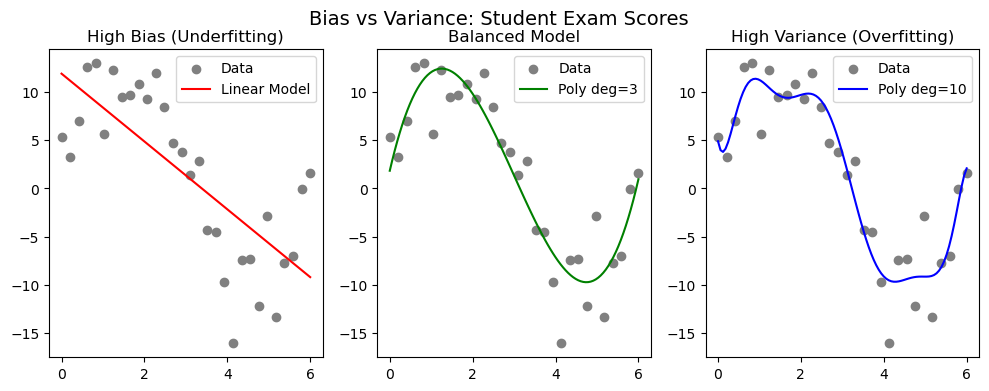

In [20]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.scatter(X, Y, color="gray", label="Data")
plt.plot(X_test, Y_linear, color="red", label="Linear Model")
plt.title("High Bias (Underfitting)")
plt.legend()

plt.subplot(1, 3, 2)
plt.scatter(X, Y, color="gray", label="Data")
plt.plot(X_test, Y_balanced, color="green", label="Poly deg=3")
plt.title("Balanced Model")
plt.legend()

plt.subplot(1, 3, 3)
plt.scatter(X, Y, color="gray", label="Data")
plt.plot(X_test, Y_poly, color="blue", label="Poly deg=10")
plt.title("High Variance (Overfitting)")
plt.legend()

plt.suptitle("Bias vs Variance: Student Exam Scores", fontsize=14)
plt.show()

In [21]:
# Scenario: Predicting Athlete Performance
# A sports academy wants to build a model to predict athlete sprint times (in seconds) based on training
#  hours. They collect data from 30 athletes, but the sprint times are noisy because of other factors (like diet, fatigue, or weather).
# They try two different models:
# - Linear Model (straight line) → very simple, assumes sprint times improve perfectly with more
#  training hours.
# - Polynomial Model (degree 10 curve) → very complex, tries to follow every bump in the data.

# Questions
# - Part A: If the linear model consistently predicts sprint times that are too fast or too slow compared
#  to actual results, what does this show about bias?
# - Part B: If the polynomial model fits the training data almost perfectly but gives very different
# predictions when tested on new athletes, what does this show about variance?
# - Part C: Which model is likely to generalize better to new athletes, and why?
# - Part D (Applied): How would you explain the difference between “high bias” and “high variance”
#  to a coach who doesn’t know machine learning?

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

In [23]:
np.random.seed(0)
# training hr
X = np.linspace(0,9,30).reshape(-1,1)
Y = (10 * np.sin(X)).ravel() + np.random.normal(scale = 3 , size = 30)

In [24]:
linear_model = make_pipeline(PolynomialFeatures(1), LinearRegression()) 
poly_model   = make_pipeline(PolynomialFeatures(10), LinearRegression())  
balanced_model = make_pipeline(PolynomialFeatures(3), LinearRegression()) 

In [25]:
linear_model.fit(X, Y)
poly_model.fit(X, Y)
balanced_model.fit(X, Y)

,steps,"[('polynomialfeatures', ...), ('linearregression', ...)]"
,transform_input,None
,memory,None
,verbose,False
,degree,3
,interaction_only,False
,include_bias,True
,order,'C'
,fit_intercept,True
,copy_X,True
,tol,1e-06


In [26]:
X_test = np.linspace(0, 6, 100).reshape(-1, 1)
y_linear   = linear_model.predict(X_test)
y_poly     = poly_model.predict(X_test)
y_balanced = balanced_model.predict(X_test)

In [27]:
plt.figure(figsize=(12, 4))

<Figure size 1200x400 with 0 Axes>

<Figure size 1200x400 with 0 Axes>

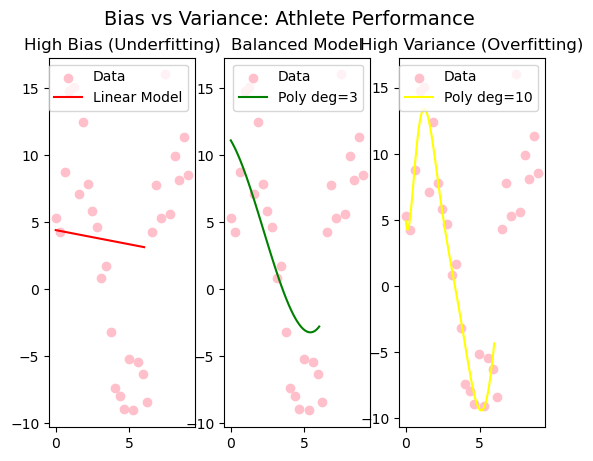

In [28]:
plt.subplot(1, 3, 1)
plt.scatter(X, Y, color="Pink", label="Data")
plt.plot(X_test, y_linear, color="red", label="Linear Model")
plt.title("High Bias (Underfitting)")
plt.legend()

plt.subplot(1, 3, 2)
plt.scatter(X, Y, color="pink", label="Data")
plt.plot(X_test, y_balanced, color="green", label="Poly deg=3")
plt.title("Balanced Model")
plt.legend()

plt.subplot(1, 3, 3)
plt.scatter(X, Y, color="pink", label="Data")
plt.plot(X_test, y_poly, color="yellow", label="Poly deg=10")
plt.title("High Variance (Overfitting)")
plt.legend()

plt.suptitle("Bias vs Variance: Athlete Performance", fontsize=14)
plt.show()